=== Dataset Summary ===
Total Rows: 6335

Missing Values per Column:
Unnamed: 0    0
title         0
text          0
label         0
dtype: int64

Duplicate Rows: 29

Class Distribution:
label
REAL    50.055249
FAKE    49.944751
Name: proportion, dtype: float64


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10876\2461094975.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette=['#2e7d32', '#c62828'])


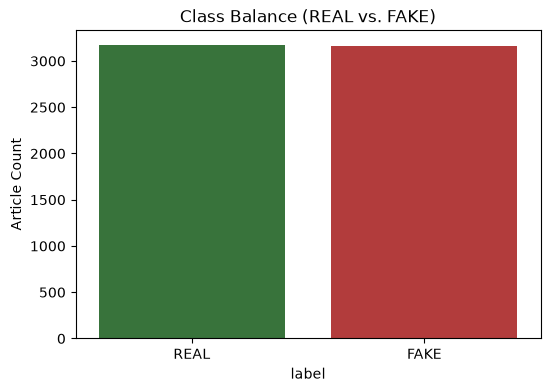

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/Fake_Real_News_Data.csv")

# 1. Basic Health Check
print("=== Dataset Summary ===")
print(f"Total Rows: {len(df)}")
print("\nMissing Values per Column:")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated(subset=['title', 'text']).sum())

# 2. Target Class Balance
print("\nClass Distribution:")
print(df['label'].value_counts(normalize=True) * 100)

# Visualizing Target Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='label', palette=['#2e7d32', '#c62828'])
plt.title("Class Balance (REAL vs. FAKE)")
plt.ylabel("Article Count")
plt.show()

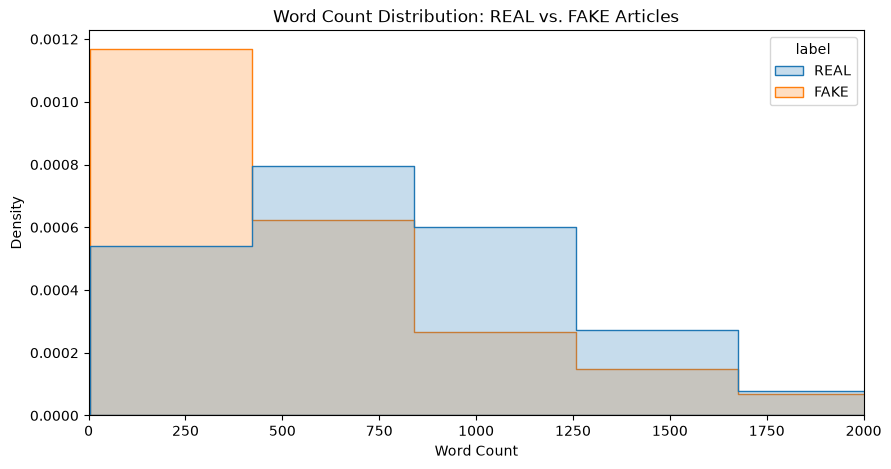

      word_count                                                               \
           count        mean         std   min    25%    50%     75%      max   
label                                                                           
FAKE      3164.0  690.262326  958.962589   3.0  222.0  433.0   840.5  20904.0   
REAL      3171.0  883.118890  723.017884  12.0  459.5  782.0  1134.5   7626.0   

      exclamation_count                                                 
                  count      mean       std  min  25%  50%  75%    max  
label                                                                   
FAKE             3164.0  0.857459  3.106636  0.0  0.0  0.0  1.0  104.0  
REAL             3171.0  0.264585  0.921015  0.0  0.0  0.0  0.0   14.0  


In [6]:
import pandas as pd

# 1. Load dataset
df = pd.read_csv("data/Fake_Real_News_Data.csv")

# 2. CREATE 'full_text' column FIRST (combining title and text)
df['full_text'] = df['title'].fillna('') + " " + df['text'].fillna('')

# 3. NOW you can run EDA calculations on 'full_text' safely
df['word_count'] = df['full_text'].apply(lambda x: len(str(x).split()))
df['char_count'] = df['full_text'].apply(lambda x: len(str(x)))
df['exclamation_count'] = df['full_text'].apply(lambda x: str(x).count('!'))

# Plot Word Count Distribution by Class
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='word_count', hue='label', element="step", stat="density", common_norm=False, bins=50)
plt.xlim(0, 2000)
plt.title("Word Count Distribution: REAL vs. FAKE Articles")
plt.xlabel("Word Count")
plt.show()

print(df.groupby('label')[['word_count', 'exclamation_count']].describe())

1. Loading Data & TF-IDF Vectorizer...
2. Training PyTorch Neural Network (Input Dim: 10000)...
Epoch 1/3 Complete. Avg Loss: 0.5484
Epoch 2/3 Complete. Avg Loss: 0.2439
Epoch 3/3 Complete. Avg Loss: 0.1275

PyTorch model trained and saved to models/pytorch_model.pth!


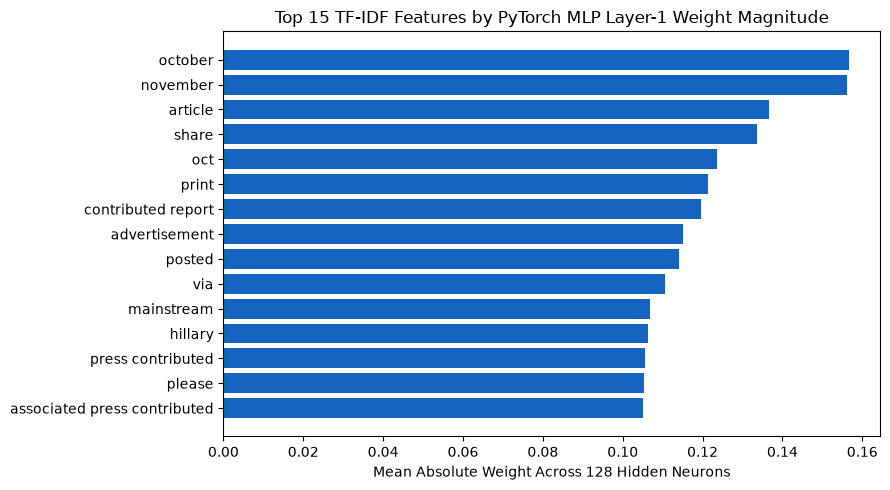

In [11]:
import joblib
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from train_pytorch import NewsClassifierNN

# 1. Load vectorizer & extract feature vocabulary (10,000 features)
vectorizer = joblib.load("models/tfidf_vectorizer.pkl")
feature_names = np.array(vectorizer.get_feature_names_out())
input_dim = len(feature_names)

# 2. Instantiate PyTorch architecture & load trained weights
model = NewsClassifierNN(input_dim=input_dim)
model.load_state_dict(torch.load("models/pytorch_model.pth", weights_only=True))
model.eval()

# 3. Compute mean absolute weight magnitude across all 128 hidden neurons
# fc1.weight shape is (128, 10000) -> mean over dim=0 yields shape (10000,)
fc1_weights = model.fc1.weight.data.abs().mean(dim=0).cpu().numpy()

# 4. Identify top 15 highest-weighted TF-IDF feature indices
top_mlp_indices = fc1_weights.argsort()[-15:][::-1]

# 5. Plot PyTorch Feature Importance
plt.figure(figsize=(9, 5))
plt.barh(feature_names[top_mlp_indices], fc1_weights[top_mlp_indices], color='#1565c0')
plt.title("Top 15 TF-IDF Features by PyTorch MLP Layer-1 Weight Magnitude")
plt.xlabel("Mean Absolute Weight Across 128 Hidden Neurons")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [10]:
from src.text_cleaner import clean_text

samples = [
    "Trump does not plan to sign the treaty before dying.",
    "Scientists did not confirm aliens in local market.",
    "Breaking news: President scheduled to speak tomorrow."
]

print(f"{'RAW TEXT':<55} | {'CLEANED TEXT (Preserved Negation)'}")
print("-" * 100)
for sample in samples:
    print(f"{sample:<55} | {clean_text(sample)}")

RAW TEXT                                                | CLEANED TEXT (Preserved Negation)
----------------------------------------------------------------------------------------------------
Trump does not plan to sign the treaty before dying.    | trump not plan sign treaty dying
Scientists did not confirm aliens in local market.      | scientists not confirm aliens local market
Breaking news: President scheduled to speak tomorrow.   | breaking news president scheduled speak tomorrow
